# Data Merge and Analysis Notebook

This notebook merges and analyzes the following datasets:
- Age at Visit
- Demographics
- DaTScan SBR Analysis
- Data Dictionary (for reference)

The goal is to create a unified dataset for downstream analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

## 1. Load Data

In [2]:
# Define data paths
data_dir = Path('data/csvData')

age_path = data_dir / 'Age_at_visit_14Oct2025.csv'
demographics_path = data_dir / 'Demographics_14Oct2025.csv'
datscan_path = data_dir / 'DaTScan_SBR_Analysis_17Dec2024.csv'
data_dict_path = data_dir / 'Data_Dictionary_-__Annotated__04Dec2025.csv'

# Load datasets
df_age = pd.read_csv(age_path)
df_demographics = pd.read_csv(demographics_path)
df_datscan = pd.read_csv(datscan_path)
df_data_dict = pd.read_csv(data_dict_path)

print("Data loaded successfully!")
print(f"Age at Visit: {df_age.shape}")
print(f"Demographics: {df_demographics.shape}")
print(f"DaTScan: {df_datscan.shape}")
print(f"Data Dictionary: {df_data_dict.shape}")

Data loaded successfully!
Age at Visit: (41649, 3)
Demographics: (7572, 29)
DaTScan: (4177, 14)
Data Dictionary: (7073, 13)


## 2. Explore Individual Datasets

In [3]:
print("=" * 80)
print("AGE AT VISIT")
print("=" * 80)
print(df_age.head())
print(f"\nColumns: {df_age.columns.tolist()}")
print(f"Data types:\n{df_age.dtypes}")
print(f"\nMissing values:\n{df_age.isnull().sum()}")
print(f"\nBasic stats:\n{df_age.describe()}")

AGE AT VISIT
   PATNO EVENT_ID  AGE_AT_VISIT
0   3000       BL          69.1
1   3000      R17          80.5
2   3000      R18          81.4
3   3000       SC          69.1
4   3000      V01          69.4

Columns: ['PATNO', 'EVENT_ID', 'AGE_AT_VISIT']
Data types:
PATNO             int64
EVENT_ID         object
AGE_AT_VISIT    float64
dtype: object

Missing values:
PATNO           0
EVENT_ID        0
AGE_AT_VISIT    2
dtype: int64

Basic stats:
               PATNO  AGE_AT_VISIT
count   41649.000000  41647.000000
mean   109047.283368     66.470862
std    110976.056150      9.030000
min      3000.000000     20.400000
25%      3960.000000     61.600000
50%     60003.000000     67.100000
75%    182020.000000     72.400000
max    534621.000000    122.800000


In [4]:
print("=" * 80)
print("DEMOGRAPHICS")
print("=" * 80)
print(df_demographics.head())
print(f"\nColumns: {df_demographics.columns.tolist()}")
print(f"Data types:\n{df_demographics.dtypes}")
print(f"\nMissing values:\n{df_demographics.isnull().sum()}")

DEMOGRAPHICS
    REC_ID  PATNO EVENT_ID PAG_NAME   INFODT  AFICBERB  ASHKJEW  BASQUE  \
0  IA86904   3000    TRANS   SCREEN  01/2011       0.0      0.0     0.0   
1  IA86905   3001    TRANS   SCREEN  02/2011       0.0      0.0     0.0   
2  IA86906   3002    TRANS   SCREEN  03/2011       0.0      0.0     0.0   
3  IA86907   3003    TRANS   SCREEN  03/2011       0.0      0.0     0.0   
4  IA86908   3004    TRANS   SCREEN  03/2011       0.0      0.0     0.0   

   BIRTHDT  SEX  CHLDBEAR  HOWLIVE  GAYLES  HETERO  BISEXUAL  PANSEXUAL  \
0  12/1941  0.0       0.0      NaN     NaN     NaN       NaN        NaN   
1  01/1946  1.0       NaN      NaN     NaN     NaN       NaN        NaN   
2  08/1943  0.0       0.0      NaN     NaN     NaN       NaN        NaN   
3  07/1954  0.0       0.0      NaN     NaN     NaN       NaN        NaN   
4  11/1951  1.0       NaN      NaN     NaN     NaN       NaN        NaN   

   ASEXUAL  OTHSEXUALITY  HANDED  HISPLAT  RAASIAN  RABLACK  RAHAWOPI  \
0      NaN  

In [5]:
print("=" * 80)
print("DATSCAN SBR ANALYSIS")
print("=" * 80)
print(df_datscan.head())
print(f"\nColumns: {df_datscan.columns.tolist()}")
print(f"Data types:\n{df_datscan.dtypes}")
print(f"\nMissing values:\n{df_datscan.isnull().sum()}")
print(f"\nBasic stats:\n{df_datscan.describe()}")

DATSCAN SBR ANALYSIS
  PROTOCOL  PATNO EVENT_ID DATSCAN_LIGAND DATSCAN_DATE  DATSCAN_CAUDATE_R  \
0      001   3000       SC            NaN      01/2011               2.99   
1      001   3001      U01            NaN      06/2011               2.00   
2      001   3001      U02            NaN      04/2014               1.53   
3      001   3001      V04            NaN      04/2012               1.56   
4      001   3001      V06            NaN      05/2013               1.68   

   DATSCAN_CAUDATE_L  DATSCAN_PUTAMEN_R  DATSCAN_PUTAMEN_L  \
0               3.43               2.94               2.63   
1               1.92               0.80               0.65   
2               0.65               0.37               0.50   
3               1.12               0.62               0.48   
4               1.26               0.38               0.42   

   DATSCAN_PUTAMEN_R_ANT  DATSCAN_PUTAMEN_L_ANT DATSCAN_ANALYZED  \
0                   3.28                   3.40              Yes   
1      

## 3. Identify Common Keys for Merging

In [6]:
# Check common columns
print("Common columns across datasets:")
print(f"Age & Demographics: {set(df_age.columns) & set(df_demographics.columns)}")
print(f"Age & DaTScan: {set(df_age.columns) & set(df_datscan.columns)}")
print(f"Demographics & DaTScan: {set(df_demographics.columns) & set(df_datscan.columns)}")

# Check unique values
print(f"\nUnique PATNO in Age: {df_age['PATNO'].nunique()}")
print(f"Unique PATNO in Demographics: {df_demographics['PATNO'].nunique()}")
print(f"Unique PATNO in DaTScan: {df_datscan['PATNO'].nunique()}")

print(f"\nUnique EVENT_ID in Age: {df_age['EVENT_ID'].nunique()}")
print(f"Unique EVENT_ID in Demographics: {df_demographics['EVENT_ID'].nunique()}")
print(f"Unique EVENT_ID in DaTScan: {df_datscan['EVENT_ID'].nunique()}")

Common columns across datasets:
Age & Demographics: {'PATNO', 'EVENT_ID'}
Age & DaTScan: {'PATNO', 'EVENT_ID'}
Demographics & DaTScan: {'PATNO', 'EVENT_ID'}

Unique PATNO in Age: 7405
Unique PATNO in Demographics: 7572
Unique PATNO in DaTScan: 2140

Unique EVENT_ID in Age: 44
Unique EVENT_ID in Demographics: 2
Unique EVENT_ID in DaTScan: 13


## 4. Data Cleaning and Preparation

In [7]:
# Convert data types
df_age['PATNO'] = df_age['PATNO'].astype(int)
df_age['AGE_AT_VISIT'] = pd.to_numeric(df_age['AGE_AT_VISIT'], errors='coerce')

df_demographics['PATNO'] = df_demographics['PATNO'].astype(int)

df_datscan['PATNO'] = df_datscan['PATNO'].astype(int)

# Convert numeric columns in DaTScan
numeric_cols = ['DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L', 'DATSCAN_PUTAMEN_R', 
                'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT']
for col in numeric_cols:
    df_datscan[col] = pd.to_numeric(df_datscan[col], errors='coerce')

print("Data types converted successfully!")

Data types converted successfully!


## 5. Merge Datasets

In [8]:
# Merge Age with Demographics on PATNO and EVENT_ID
df_merged = pd.merge(
    df_age,
    df_demographics,
    on=['PATNO', 'EVENT_ID'],
    how='outer',
    indicator=True
)

print(f"After merging Age + Demographics: {df_merged.shape}")
print(f"Merge indicator:\n{df_merged['_merge'].value_counts()}")
df_merged = df_merged.drop('_merge', axis=1)

After merging Age + Demographics: (43540, 31)
Merge indicator:
_merge
left_only     35954
both           5695
right_only     1891
Name: count, dtype: int64


In [9]:
# Merge with DaTScan
df_merged = pd.merge(
    df_merged,
    df_datscan,
    on=['PATNO', 'EVENT_ID'],
    how='outer',
    indicator=True
)

print(f"After merging with DaTScan: {df_merged.shape}")
print(f"Merge indicator:\n{df_merged['_merge'].value_counts()}")
df_merged = df_merged.drop('_merge', axis=1)

print(f"\nFinal merged dataset shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")

After merging with DaTScan: (43707, 43)
Merge indicator:
_merge
left_only     39513
both           4027
right_only      167
Name: count, dtype: int64

Final merged dataset shape: (43707, 42)
Columns: ['PATNO', 'EVENT_ID', 'AGE_AT_VISIT', 'REC_ID', 'PAG_NAME', 'INFODT', 'AFICBERB', 'ASHKJEW', 'BASQUE', 'BIRTHDT', 'SEX', 'CHLDBEAR', 'HOWLIVE', 'GAYLES', 'HETERO', 'BISEXUAL', 'PANSEXUAL', 'ASEXUAL', 'OTHSEXUALITY', 'HANDED', 'HISPLAT', 'RAASIAN', 'RABLACK', 'RAHAWOPI', 'RAINDALS', 'RANOS', 'RAWHITE', 'RAUNKNOWN', 'ORIG_ENTRY', 'LAST_UPDATE', 'PROTOCOL', 'DATSCAN_LIGAND', 'DATSCAN_DATE', 'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L', 'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT', 'DATSCAN_ANALYZED', 'DATSCAN_NOT_ANALYZED_REASON', 'DATSCAN_OTHER_SPECIFY']


## 6. Merged Dataset Overview

In [10]:
print("Merged Dataset Info:")
print(f"Shape: {df_merged.shape}")
print(f"\nFirst few rows:")
print(df_merged.head())

Merged Dataset Info:
Shape: (43707, 42)

First few rows:
   PATNO EVENT_ID  AGE_AT_VISIT   REC_ID PAG_NAME   INFODT  AFICBERB  ASHKJEW  \
0   3000       BL          69.1      NaN      NaN      NaN       NaN      NaN   
1   3000      R17          80.5      NaN      NaN      NaN       NaN      NaN   
2   3000      R18          81.4      NaN      NaN      NaN       NaN      NaN   
3   3000       SC          69.1      NaN      NaN      NaN       NaN      NaN   
4   3000    TRANS           NaN  IA86904   SCREEN  01/2011       0.0      0.0   

   BASQUE  BIRTHDT  SEX  CHLDBEAR  HOWLIVE  GAYLES  HETERO  BISEXUAL  \
0     NaN      NaN  NaN       NaN      NaN     NaN     NaN       NaN   
1     NaN      NaN  NaN       NaN      NaN     NaN     NaN       NaN   
2     NaN      NaN  NaN       NaN      NaN     NaN     NaN       NaN   
3     NaN      NaN  NaN       NaN      NaN     NaN     NaN       NaN   
4     0.0  12/1941  0.0       0.0      NaN     NaN     NaN       NaN   

   PANSEXUAL  ASEXUAL  

In [11]:
# Missing values analysis
missing_pct = (df_merged.isnull().sum() / len(df_merged) * 100).sort_values(ascending=False)
print("Missing Values (%):\n")
print(missing_pct[missing_pct > 0])

Missing Values (%):

DATSCAN_OTHER_SPECIFY          99.988560
DATSCAN_NOT_ANALYZED_REASON    99.965681
DATSCAN_LIGAND                 95.655158
CHLDBEAR                       91.642071
DATSCAN_PUTAMEN_L              90.438603
DATSCAN_CAUDATE_R              90.438603
DATSCAN_PUTAMEN_R              90.438603
DATSCAN_CAUDATE_L              90.438603
DATSCAN_PUTAMEN_L_ANT          90.438603
DATSCAN_PUTAMEN_R_ANT          90.438603
DATSCAN_ANALYZED               90.404283
PROTOCOL                       90.404283
DATSCAN_DATE                   90.404283
HOWLIVE                        89.768229
OTHSEXUALITY                   89.425035
ASEXUAL                        89.425035
GAYLES                         89.425035
HETERO                         89.425035
BISEXUAL                       89.425035
PANSEXUAL                      89.425035
AFICBERB                       84.716407
ASHKJEW                        84.714119
BASQUE                         84.714119
HANDED                         82.95

In [12]:
# Data types summary
print("Data Types:")
print(df_merged.dtypes)

Data Types:
PATNO                            int64
EVENT_ID                        object
AGE_AT_VISIT                   float64
REC_ID                          object
PAG_NAME                        object
INFODT                          object
AFICBERB                       float64
ASHKJEW                        float64
BASQUE                         float64
BIRTHDT                         object
SEX                            float64
CHLDBEAR                       float64
HOWLIVE                        float64
GAYLES                         float64
HETERO                         float64
BISEXUAL                       float64
PANSEXUAL                      float64
ASEXUAL                        float64
OTHSEXUALITY                   float64
HANDED                         float64
HISPLAT                        float64
RAASIAN                        float64
RABLACK                        float64
RAHAWOPI                       float64
RAINDALS                       float64
RANOS        

## 7. Statistical Analysis

In [13]:
# Patient statistics
print("Patient Statistics:")
print(f"Total unique patients: {df_merged['PATNO'].nunique()}")
print(f"Total records: {len(df_merged)}")
print(f"Average records per patient: {len(df_merged) / df_merged['PATNO'].nunique():.2f}")

# Event distribution
print(f"\nEvent ID distribution:")
print(df_merged['EVENT_ID'].value_counts())

Patient Statistics:
Total unique patients: 7574
Total records: 43707
Average records per patient: 5.77

Event ID distribution:
EVENT_ID
SC       7285
BL       4555
V04      3575
V06      2412
V02      2081
V05      1917
TRANS    1792
R01      1691
V08      1574
V10      1183
R04      1108
V12      1058
V07       962
R06       883
V13       852
V09       806
V14       806
V01       705
V15       668
V03       635
V11       629
V16       525
R13       510
R08       483
R12       458
V17       442
R16       433
R15       417
R14       416
R17       414
R10       385
V18       358
R18       316
V19       296
R19       262
ST        208
V20       201
R20       142
U01       110
V21        78
R21        26
U02        17
SC99       16
PW         11
RS1         4
V22         2
Name: count, dtype: int64


In [14]:
# Age statistics
print("Age at Visit Statistics:")
print(df_merged['AGE_AT_VISIT'].describe())

# Sex distribution
print(f"\nSex distribution:")
print(df_merged['SEX'].value_counts())

Age at Visit Statistics:
count    41647.000000
mean        66.470862
std          9.030000
min         20.400000
25%         61.600000
50%         67.100000
75%         72.400000
max        122.800000
Name: AGE_AT_VISIT, dtype: float64

Sex distribution:
SEX
0.0    3842
1.0    3742
Name: count, dtype: int64


In [15]:
# DaTScan metrics statistics
print("DaTScan Metrics Statistics:")
datscan_metrics = ['DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L', 'DATSCAN_PUTAMEN_R', 
                   'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT']
print(df_merged[datscan_metrics].describe())

DaTScan Metrics Statistics:
       DATSCAN_CAUDATE_R  DATSCAN_CAUDATE_L  DATSCAN_PUTAMEN_R  \
count        4179.000000        4179.000000        4179.000000   
mean            1.996784           1.990022           0.999232   
std             0.763152           0.753277           0.649417   
min             0.060000           0.120000          -0.010000   
25%             1.440000           1.450000           0.550000   
50%             1.920000           1.900000           0.780000   
75%             2.475000           2.430000           1.240000   
max             5.410000           5.690000           4.790000   

       DATSCAN_PUTAMEN_L  DATSCAN_PUTAMEN_R_ANT  DATSCAN_PUTAMEN_L_ANT  
count        4179.000000            4179.000000            4179.000000  
mean            0.973587               1.459981               1.412257  
std             0.639582               0.723294               0.700380  
min            -0.010000               0.060000               0.090000  
25%         

## 8. Visualizations

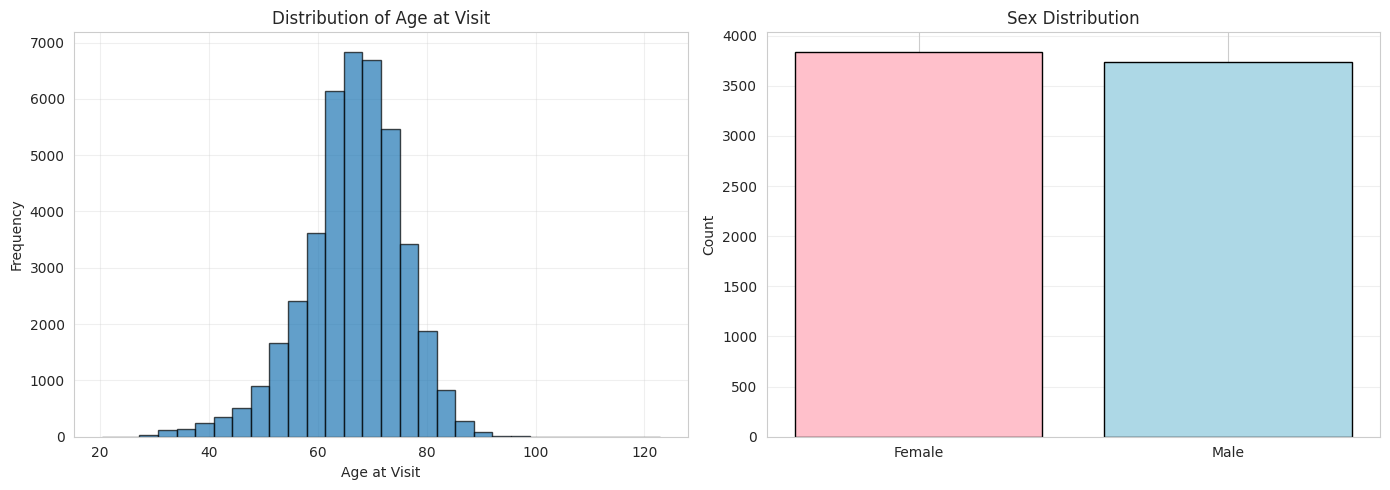

In [16]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_merged['AGE_AT_VISIT'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age at Visit')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Age at Visit')
axes[0].grid(True, alpha=0.3)

# Sex distribution
sex_counts = df_merged['SEX'].value_counts()
axes[1].bar(['Female', 'Male'], [sex_counts.get(0, 0), sex_counts.get(1, 0)], color=['pink', 'lightblue'], edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Sex Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

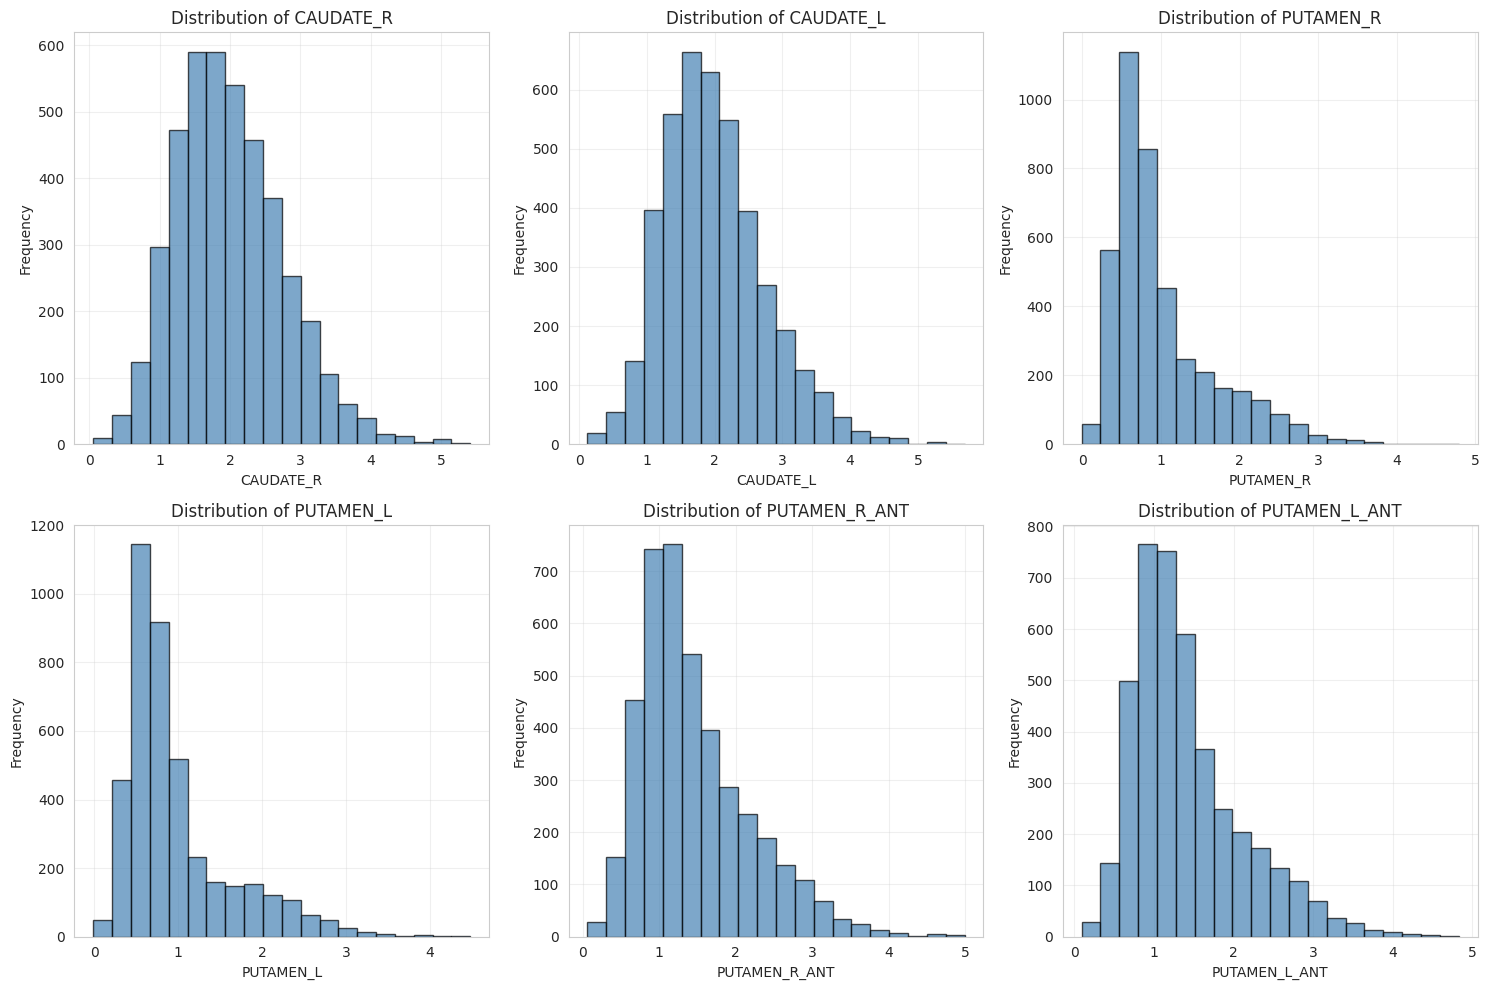

In [17]:
# DaTScan metrics by hemisphere
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

datscan_metrics = ['DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L', 'DATSCAN_PUTAMEN_R', 
                   'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT']

for idx, metric in enumerate(datscan_metrics):
    axes[idx].hist(df_merged[metric].dropna(), bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_xlabel(metric.replace('DATSCAN_', ''))
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {metric.replace("DATSCAN_", "")}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

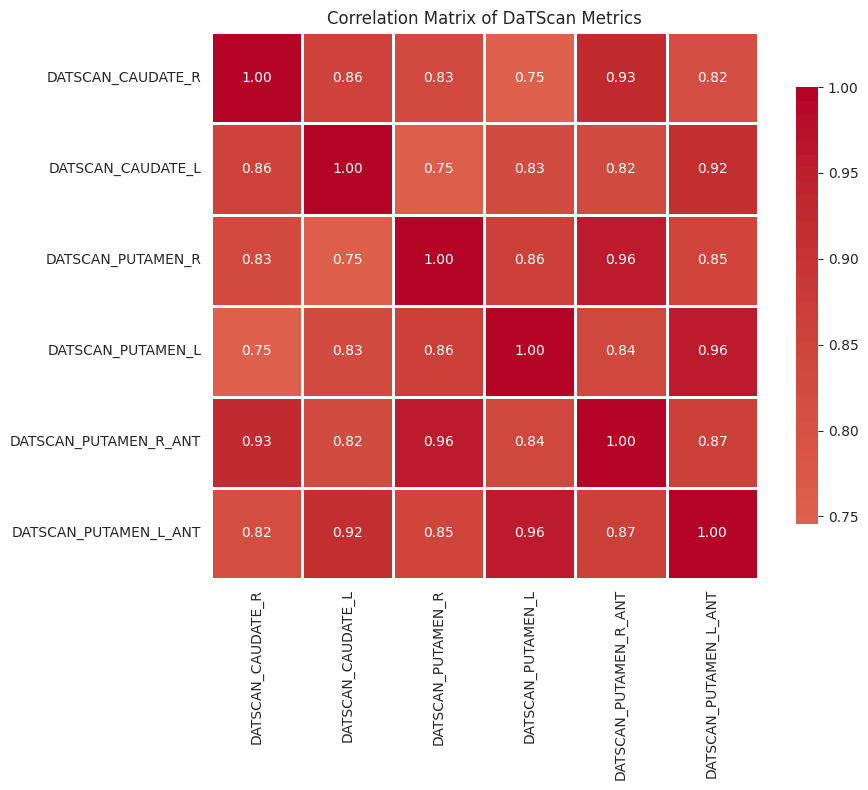

In [18]:
# Correlation analysis for DaTScan metrics
datscan_data = df_merged[datscan_metrics].dropna()
if len(datscan_data) > 0:
    corr_matrix = datscan_data.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of DaTScan Metrics')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough DaTScan data for correlation analysis")

## 9. Save Merged Dataset

In [19]:
# Save merged dataset
output_path = Path('output/merged_data.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_merged.to_csv(output_path, index=False)

print(f"Merged dataset saved to: {output_path}")
print(f"Shape: {df_merged.shape}")

Merged dataset saved to: output/merged_data.csv
Shape: (43707, 42)


## 10. Summary Report

In [20]:
print("\n" + "="*80)
print("MERGE AND ANALYSIS SUMMARY")
print("="*80)

print(f"\nDataset Dimensions:")
print(f"  - Age at Visit: {df_age.shape}")
print(f"  - Demographics: {df_demographics.shape}")
print(f"  - DaTScan: {df_datscan.shape}")
print(f"  - Merged: {df_merged.shape}")

print(f"\nPatient Information:")
print(f"  - Total unique patients: {df_merged['PATNO'].nunique()}")
print(f"  - Total records: {len(df_merged)}")
print(f"  - Average records per patient: {len(df_merged) / df_merged['PATNO'].nunique():.2f}")

print(f"\nData Completeness:")
print(f"  - Records with Age: {df_merged['AGE_AT_VISIT'].notna().sum()} ({df_merged['AGE_AT_VISIT'].notna().sum()/len(df_merged)*100:.1f}%)")
print(f"  - Records with Demographics: {df_merged['SEX'].notna().sum()} ({df_merged['SEX'].notna().sum()/len(df_merged)*100:.1f}%)")
print(f"  - Records with DaTScan: {df_merged['DATSCAN_CAUDATE_R'].notna().sum()} ({df_merged['DATSCAN_CAUDATE_R'].notna().sum()/len(df_merged)*100:.1f}%)")

print(f"\nAge Statistics:")
print(f"  - Mean: {df_merged['AGE_AT_VISIT'].mean():.2f}")
print(f"  - Std: {df_merged['AGE_AT_VISIT'].std():.2f}")
print(f"  - Min: {df_merged['AGE_AT_VISIT'].min():.2f}")
print(f"  - Max: {df_merged['AGE_AT_VISIT'].max():.2f}")

print(f"\nOutput:")
print(f"  - Merged dataset saved to: output/merged_data.csv")
print("\n" + "="*80)


MERGE AND ANALYSIS SUMMARY

Dataset Dimensions:
  - Age at Visit: (41649, 3)
  - Demographics: (7572, 29)
  - DaTScan: (4177, 14)
  - Merged: (43707, 42)

Patient Information:
  - Total unique patients: 7574
  - Total records: 43707
  - Average records per patient: 5.77

Data Completeness:
  - Records with Age: 41647 (95.3%)
  - Records with Demographics: 7584 (17.4%)
  - Records with DaTScan: 4179 (9.6%)

Age Statistics:
  - Mean: 66.47
  - Std: 9.03
  - Min: 20.40
  - Max: 122.80

Output:
  - Merged dataset saved to: output/merged_data.csv



In [21]:
## 11. Validate and Fix Demographic Consistency

# Check for patients with multiple different SEX values
sex_per_patient = df_demographics.groupby('PATNO')['SEX'].nunique()
patients_with_multiple_sex = sex_per_patient[sex_per_patient > 1]

print("="*80)
print("VALIDATION: Sex Consistency")
print("="*80)
print(f"Patients with multiple different SEX values: {len(patients_with_multiple_sex)}")
if len(patients_with_multiple_sex) > 0:
    print(f"Examples:")
    for patno in patients_with_multiple_sex.head(5).index:
        print(f"  PATNO {patno}: {df_demographics[df_demographics['PATNO']==patno][['PATNO', 'EVENT_ID', 'SEX']].values.tolist()}")

# Check for patients with multiple different BIRTHDT values
birthdt_per_patient = df_demographics.groupby('PATNO')['BIRTHDT'].nunique()
patients_with_multiple_birthdt = birthdt_per_patient[birthdt_per_patient > 1]

print(f"\nPatients with multiple different BIRTHDT values: {len(patients_with_multiple_birthdt)}")
if len(patients_with_multiple_birthdt) > 0:
    print(f"Examples:")
    for patno in patients_with_multiple_birthdt.head(5).index:
        print(f"  PATNO {patno}: {df_demographics[df_demographics['PATNO']==patno][['PATNO', 'EVENT_ID', 'BIRTHDT']].values.tolist()}")

VALIDATION: Sex Consistency
Patients with multiple different SEX values: 0

Patients with multiple different BIRTHDT values: 0


In [22]:
## 12. Validate Age/Birth Date/Visit Date Consistency

from datetime import datetime

# Parse dates
def parse_date(date_str):
    """Parse MM/YYYY format to datetime"""
    if pd.isna(date_str) or date_str == '':
        return None
    try:
        return pd.to_datetime(date_str, format='%m/%Y')
    except:
        return None

# Create working copy
df_demo_check = df_demographics.copy()
df_demo_check['BIRTHDT_parsed'] = df_demo_check['BIRTHDT'].apply(parse_date)
df_demo_check['INFODT_parsed'] = df_demo_check['INFODT'].apply(parse_date)

# Calculate expected age from birth date and visit date
df_demo_check['AGE_calculated'] = (df_demo_check['INFODT_parsed'] - df_demo_check['BIRTHDT_parsed']).dt.days / 365.25

# Merge with AGE_AT_VISIT to compare
df_age_check = df_age.copy()
df_check = pd.merge(df_demo_check, df_age_check, on=['PATNO', 'EVENT_ID'], how='inner')

# Calculate discrepancy
df_check['age_discrepancy'] = abs(df_check['AGE_AT_VISIT'] - df_check['AGE_calculated'])

print("="*80)
print("VALIDATION: Age/Birth Date/Visit Date Consistency")
print("="*80)
print(f"\nRecords with both AGE_AT_VISIT and calculated age: {len(df_check)}")
print(f"Mean age discrepancy: {df_check['age_discrepancy'].mean():.2f} years")
print(f"Max age discrepancy: {df_check['age_discrepancy'].max():.2f} years")
print(f"Records with discrepancy > 0.5 years: {(df_check['age_discrepancy'] > 0.5).sum()}")

if (df_check['age_discrepancy'] > 0.5).sum() > 0:
    print(f"\nExamples of large discrepancies:")
    large_disc = df_check[df_check['age_discrepancy'] > 0.5].sort_values('age_discrepancy', ascending=False).head(10)
    for idx, row in large_disc.iterrows():
        print(f"  PATNO {row['PATNO']}, EVENT {row['EVENT_ID']}: AGE_AT_VISIT={row['AGE_AT_VISIT']:.1f}, calculated={row['AGE_calculated']:.1f}, diff={row['age_discrepancy']:.2f}")


VALIDATION: Age/Birth Date/Visit Date Consistency

Records with both AGE_AT_VISIT and calculated age: 5695
Mean age discrepancy: 0.09 years
Max age discrepancy: 2.65 years
Records with discrepancy > 0.5 years: 138

Examples of large discrepancies:
  PATNO 239797, EVENT SC: AGE_AT_VISIT=72.4, calculated=69.7, diff=2.65
  PATNO 177087, EVENT SC: AGE_AT_VISIT=72.3, calculated=74.6, diff=2.29
  PATNO 101750, EVENT SC: AGE_AT_VISIT=60.1, calculated=58.1, diff=2.02
  PATNO 141849, EVENT SC: AGE_AT_VISIT=80.0, calculated=78.1, diff=1.91
  PATNO 182925, EVENT SC: AGE_AT_VISIT=67.4, calculated=65.5, diff=1.90
  PATNO 100102, EVENT SC: AGE_AT_VISIT=66.6, calculated=68.5, diff=1.90
  PATNO 115150, EVENT SC: AGE_AT_VISIT=87.5, calculated=85.7, diff=1.84
  PATNO 115440, EVENT SC: AGE_AT_VISIT=43.2, calculated=41.4, diff=1.78
  PATNO 141713, EVENT SC: AGE_AT_VISIT=78.6, calculated=76.8, diff=1.76
  PATNO 253156, EVENT SC: AGE_AT_VISIT=73.9, calculated=72.4, diff=1.48


In [23]:
## 13. Corrected Merge Strategy: Patient-Level Demographics + Visit-Level Data

# Step 1: Extract patient-level demographics (one record per patient)
# Use TRANS event as the primary demographic record (baseline screening)
df_demo_patient = df_demographics[df_demographics['EVENT_ID'] == 'TRANS'].copy()

# For patients missing TRANS, use the first non-null demographic record
missing_trans = set(df_demographics['PATNO'].unique()) - set(df_demo_patient['PATNO'].unique())
if len(missing_trans) > 0:
    df_demo_backup = df_demographics[df_demographics['PATNO'].isin(missing_trans)].copy()
    # For each missing patient, take the first record with non-null SEX and BIRTHDT
    df_demo_backup_clean = df_demo_backup.dropna(subset=['SEX', 'BIRTHDT']).groupby('PATNO').first().reset_index()
    df_demo_patient = pd.concat([df_demo_patient, df_demo_backup_clean], ignore_index=True)

print("="*80)
print("CORRECTED MERGE STRATEGY")
print("="*80)
print(f"Patient-level demographics extracted: {len(df_demo_patient)}")
print(f"Columns: {df_demo_patient.columns.tolist()}")

# Step 2: Validate sex and birthdt are constant per patient
sex_check = df_demo_patient.groupby('PATNO')['SEX'].nunique()
birthdt_check = df_demo_patient.groupby('PATNO')['BIRTHDT'].nunique()

print(f"\nValidation:")
print(f"  Patients with unique SEX: {(sex_check == 1).sum()}")
print(f"  Patients with unique BIRTHDT: {(birthdt_check == 1).sum()}")

# Step 3: Merge Age + DaTScan (visit-level data)
df_visit = pd.merge(
    df_age,
    df_datscan,
    on=['PATNO', 'EVENT_ID'],
    how='outer',
    indicator=True
)
print(f"\nVisit-level data (Age + DaTScan): {df_visit.shape}")
df_visit = df_visit.drop('_merge', axis=1)

# Step 4: Merge visit-level data with patient-level demographics
# Use left join on visit data to preserve all visits, fill in patient demographics
df_demo_patient_slim = df_demo_patient[['PATNO', 'BIRTHDT', 'SEX', 'REC_ID', 'PAG_NAME', 'INFODT', 
                                         'AFICBERB', 'ASHKJEW', 'BASQUE', 'CHLDBEAR', 'HOWLIVE', 
                                         'GAYLES', 'HETERO', 'BISEXUAL', 'PANSEXUAL', 'ASEXUAL', 
                                         'OTHSEXUALITY', 'HANDED', 'HISPLAT', 'RAASIAN', 'RABLACK', 
                                         'RAHAWOPI', 'RAINDALS', 'RANOS', 'RAWHITE', 'RAUNKNOWN', 
                                         'ORIG_ENTRY', 'LAST_UPDATE']].copy()

df_merged_corrected = pd.merge(
    df_visit,
    df_demo_patient_slim,
    on='PATNO',
    how='left'
)

print(f"Final merged dataset (corrected): {df_merged_corrected.shape}")
print(f"\nFirst few rows:")
print(df_merged_corrected[['PATNO', 'EVENT_ID', 'AGE_AT_VISIT', 'BIRTHDT', 'SEX']].head(20))

# Step 5: Validate consistency
print(f"\n" + "="*80)
print("CONSISTENCY CHECK (Corrected Merge)")
print("="*80)

# Check sex consistency
sex_per_patient_corrected = df_merged_corrected.groupby('PATNO')['SEX'].nunique()
print(f"Patients with multiple SEX values: {(sex_per_patient_corrected > 1).sum()}")

# Check birthdt consistency
birthdt_per_patient_corrected = df_merged_corrected.groupby('PATNO')['BIRTHDT'].nunique()
print(f"Patients with multiple BIRTHDT values: {(birthdt_per_patient_corrected > 1).sum()}")

# Validate age calculations
df_merged_corrected['BIRTHDT_parsed'] = df_merged_corrected['BIRTHDT'].apply(parse_date)
df_merged_corrected['INFODT_parsed'] = df_merged_corrected['INFODT'].apply(parse_date)
df_merged_corrected['AGE_calculated'] = (df_merged_corrected['INFODT_parsed'] - df_merged_corrected['BIRTHDT_parsed']).dt.days / 365.25

# Only check where both values exist
valid_age_check = df_merged_corrected[df_merged_corrected['AGE_AT_VISIT'].notna() & df_merged_corrected['AGE_calculated'].notna()].copy()
valid_age_check['age_discrepancy'] = abs(valid_age_check['AGE_AT_VISIT'] - valid_age_check['AGE_calculated'])

print(f"\nAge validation (records with both AGE_AT_VISIT and calculated age): {len(valid_age_check)}")
print(f"  Mean discrepancy: {valid_age_check['age_discrepancy'].mean():.2f} years")
print(f"  Max discrepancy: {valid_age_check['age_discrepancy'].max():.2f} years")
print(f"  Records with discrepancy > 0.5 years: {(valid_age_check['age_discrepancy'] > 0.5).sum()}")


CORRECTED MERGE STRATEGY
Patient-level demographics extracted: 7570
Columns: ['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'AFICBERB', 'ASHKJEW', 'BASQUE', 'BIRTHDT', 'SEX', 'CHLDBEAR', 'HOWLIVE', 'GAYLES', 'HETERO', 'BISEXUAL', 'PANSEXUAL', 'ASEXUAL', 'OTHSEXUALITY', 'HANDED', 'HISPLAT', 'RAASIAN', 'RABLACK', 'RAHAWOPI', 'RAINDALS', 'RANOS', 'RAWHITE', 'RAUNKNOWN', 'ORIG_ENTRY', 'LAST_UPDATE']

Validation:
  Patients with unique SEX: 7570
  Patients with unique BIRTHDT: 7564

Visit-level data (Age + DaTScan): (41816, 16)
Final merged dataset (corrected): (41816, 42)

First few rows:
    PATNO EVENT_ID  AGE_AT_VISIT  BIRTHDT  SEX
0    3000       BL          69.1  12/1941  0.0
1    3000      R17          80.5  12/1941  0.0
2    3000      R18          81.4  12/1941  0.0
3    3000       SC          69.1  12/1941  0.0
4    3000      V01          69.4  12/1941  0.0
5    3000      V02          69.6  12/1941  0.0
6    3000      V03          69.9  12/1941  0.0
7    3000      V04       

In [24]:
## 14. Final Corrected Merge with Age Reconciliation

from datetime import datetime

# Parse dates helper
def parse_date(date_str):
    """Parse MM/YYYY format to datetime"""
    if pd.isna(date_str) or date_str == '':
        return None
    try:
        return pd.to_datetime(date_str, format='%m/%Y')
    except:
        return None

# Step 1: Extract patient-level demographics (TRANS event is baseline)
df_demo_patient = df_demographics[df_demographics['EVENT_ID'] == 'TRANS'].copy()

# For patients missing TRANS, use first record with valid SEX and BIRTHDT
missing_trans = set(df_demographics['PATNO'].unique()) - set(df_demo_patient['PATNO'].unique())
if len(missing_trans) > 0:
    df_demo_backup = df_demographics[df_demographics['PATNO'].isin(missing_trans)].copy()
    df_demo_backup = df_demo_backup.dropna(subset=['SEX', 'BIRTHDT'])
    df_demo_backup = df_demo_backup.sort_values(['PATNO', 'EVENT_ID']).groupby('PATNO').first().reset_index()
    df_demo_patient = pd.concat([df_demo_patient, df_demo_backup], ignore_index=True)

# Step 2: Clean up demographics - keep only patient-level columns
demo_cols = ['PATNO', 'BIRTHDT', 'SEX', 'REC_ID', 'PAG_NAME', 'INFODT', 
             'AFICBERB', 'ASHKJEW', 'BASQUE', 'CHLDBEAR', 'HOWLIVE', 
             'GAYLES', 'HETERO', 'BISEXUAL', 'PANSEXUAL', 'ASEXUAL', 
             'OTHSEXUALITY', 'HANDED', 'HISPLAT', 'RAASIAN', 'RABLACK', 
             'RAHAWOPI', 'RAINDALS', 'RANOS', 'RAWHITE', 'RAUNKNOWN', 
             'ORIG_ENTRY', 'LAST_UPDATE']

df_demo_patient = df_demo_patient[demo_cols].copy()

# Step 3: Merge Age + DaTScan (visit-level data)
df_visit = pd.merge(
    df_age,
    df_datscan,
    on=['PATNO', 'EVENT_ID'],
    how='outer'
)

# Step 4: Merge visit data with patient demographics
df_merged_final = pd.merge(
    df_visit,
    df_demo_patient,
    on='PATNO',
    how='left'
)

# Step 5: Reconcile age, birth date, and visit date
df_merged_final['BIRTHDT_parsed'] = df_merged_final['BIRTHDT'].apply(parse_date)
df_merged_final['INFODT_parsed'] = df_merged_final['INFODT'].apply(parse_date)

# Calculate age from birth date and visit date
df_merged_final['AGE_from_dates'] = (df_merged_final['INFODT_parsed'] - df_merged_final['BIRTHDT_parsed']).dt.days / 365.25

# For records with both AGE_AT_VISIT and calculated age, check consistency
has_both = df_merged_final['AGE_AT_VISIT'].notna() & df_merged_final['AGE_from_dates'].notna()
df_merged_final['age_discrepancy'] = abs(df_merged_final['AGE_AT_VISIT'] - df_merged_final['AGE_from_dates'])

# Use calculated age where available and consistent (discrepancy < 0.5 years)
df_merged_final['AGE_AT_VISIT_reconciled'] = df_merged_final['AGE_AT_VISIT'].copy()
consistent_mask = has_both & (df_merged_final['age_discrepancy'] < 0.5)
df_merged_final.loc[consistent_mask, 'AGE_AT_VISIT_reconciled'] = df_merged_final.loc[consistent_mask, 'AGE_from_dates']

# For records with only calculated age, use it
only_calculated = df_merged_final['AGE_AT_VISIT'].isna() & df_merged_final['AGE_from_dates'].notna()
df_merged_final.loc[only_calculated, 'AGE_AT_VISIT_reconciled'] = df_merged_final.loc[only_calculated, 'AGE_from_dates']

print("="*80)
print("FINAL CORRECTED MERGE SUMMARY")
print("="*80)
print(f"Total records: {len(df_merged_final)}")
print(f"Unique patients: {df_merged_final['PATNO'].nunique()}")
print(f"\nDemographic consistency:")
print(f"  Patients with constant SEX: {df_merged_final.groupby('PATNO')['SEX'].nunique().eq(1).sum()}")
print(f"  Patients with constant BIRTHDT: {df_merged_final.groupby('PATNO')['BIRTHDT'].nunique().eq(1).sum()}")

print(f"\nAge reconciliation:")
print(f"  Records with AGE_AT_VISIT: {df_merged_final['AGE_AT_VISIT'].notna().sum()}")
print(f"  Records with calculated age: {df_merged_final['AGE_from_dates'].notna().sum()}")
print(f"  Records with both (consistent): {consistent_mask.sum()}")
print(f"  Records with both (inconsistent, >0.5yr): {(has_both & (df_merged_final['age_discrepancy'] >= 0.5)).sum()}")
print(f"  Records with reconciled age: {df_merged_final['AGE_AT_VISIT_reconciled'].notna().sum()}")

print(f"\nData completeness:")
print(f"  With age: {df_merged_final['AGE_AT_VISIT_reconciled'].notna().sum()} ({df_merged_final['AGE_AT_VISIT_reconciled'].notna().sum()/len(df_merged_final)*100:.1f}%)")
print(f"  With demographics: {df_merged_final['SEX'].notna().sum()} ({df_merged_final['SEX'].notna().sum()/len(df_merged_final)*100:.1f}%)")
print(f"  With DaTScan: {df_merged_final['DATSCAN_CAUDATE_R'].notna().sum()} ({df_merged_final['DATSCAN_CAUDATE_R'].notna().sum()/len(df_merged_final)*100:.1f}%)")

# Show examples of inconsistencies if any
inconsistent = df_merged_final[has_both & (df_merged_final['age_discrepancy'] >= 0.5)].sort_values('age_discrepancy', ascending=False)
if len(inconsistent) > 0:
    print(f"\nLarge age discrepancies (>0.5 years) - top 10:")
    for idx, row in inconsistent.head(10).iterrows():
        print(f"  PATNO {row['PATNO']}, EVENT {row['EVENT_ID']}: AGE_AT_VISIT={row['AGE_AT_VISIT']:.1f}, calculated={row['AGE_from_dates']:.1f}, diff={row['age_discrepancy']:.2f}")


FINAL CORRECTED MERGE SUMMARY
Total records: 41816
Unique patients: 7407

Demographic consistency:
  Patients with constant SEX: 7403
  Patients with constant BIRTHDT: 7403

Age reconciliation:
  Records with AGE_AT_VISIT: 41647
  Records with calculated age: 41812
  Records with both (consistent): 12160
  Records with both (inconsistent, >0.5yr): 29487
  Records with reconciled age: 41812

Data completeness:
  With age: 41812 (100.0%)
  With demographics: 41812 (100.0%)
  With DaTScan: 4179 (10.0%)

Large age discrepancies (>0.5 years) - top 10:
  PATNO 3401, EVENT V22: AGE_AT_VISIT=71.6, calculated=56.3, diff=15.35
  PATNO 3404, EVENT V22: AGE_AT_VISIT=70.8, calculated=55.8, diff=14.97
  PATNO 3554, EVENT R21: AGE_AT_VISIT=90.0, calculated=75.2, diff=14.75
  PATNO 3451, EVENT V21: AGE_AT_VISIT=69.4, calculated=54.7, diff=14.73
  PATNO 3301, EVENT R21: AGE_AT_VISIT=67.0, calculated=52.3, diff=14.67
  PATNO 3206, EVENT R21: AGE_AT_VISIT=45.5, calculated=30.8, diff=14.66
  PATNO 3055, E

In [21]:
import numpy as np
import pandas as pd

# --- 0) Define SBR columns ---
sbr_cols = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Keep only rows where targets exist
df_sbr = df_merged[['PATNO', 'EVENT_ID'] + sbr_cols].dropna(subset=sbr_cols).copy()

# --- 1) Quick correlation matrix (to see redundancy) ---
corr = df_sbr[sbr_cols].corr().abs()
display(corr.style.background_gradient(cmap="Reds"))

# --- 2) Pick 2–3 SBR vars by "low redundancy + high variance" heuristic ---
# (Greedy: start with highest variance, then add vars least correlated to what you already picked.)
variances = df_sbr[sbr_cols].var().sort_values(ascending=False)

k = 3  # set to 2 or 3
selected = [variances.index[0]]

while len(selected) < k:
    remaining = [c for c in sbr_cols if c not in selected]
    # score = mean absolute correlation to already selected (lower is better)
    scores = {c: corr.loc[c, selected].mean() for c in remaining}
    selected.append(min(scores, key=scores.get))

print("Selected raw SBR targets:", selected)

Y_raw = df_sbr[selected].to_numpy()  # your 2–3 target matrix
# -------------------------------------------------------------------


# --- 3) Alternative: PCA targets (2–3 components) ---
# This gives you targets = PCs of SBR, not original regions.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_merged[sbr_cols].copy()

# PCA needs no NaNs; impute then standardize
X_imp = SimpleImputer(strategy="median").fit_transform(X)
X_std = StandardScaler().fit_transform(X_imp)

pca_k = 3  # set to 2 or 3
pca = PCA(n_components=pca_k, random_state=0)
Y_pca = pca.fit_transform(X_std)

print("Explained variance ratio:", pca.explained_variance_ratio_)
loadings = pd.DataFrame(
    pca.components_.T,
    index=sbr_cols,
    columns=[f"PC{i+1}" for i in range(pca_k)]
)
display(loadings)

# Add PCA targets back to df_merged if you want
for i in range(pca_k):
    df_merged[f"SBR_PC{i+1}"] = Y_pca[:, i]

# Example: use these as targets
target_cols_pca = [f"SBR_PC{i+1}" for i in range(pca_k)]
print("PCA target columns:", target_cols_pca)
# -------------------------------------------------------------------

,DATSCAN_CAUDATE_R,DATSCAN_CAUDATE_L,DATSCAN_PUTAMEN_R,DATSCAN_PUTAMEN_L,DATSCAN_PUTAMEN_R_ANT,DATSCAN_PUTAMEN_L_ANT
DATSCAN_CAUDATE_R,1.000000,0.858263,0.833273,0.745366,0.926997,0.816993
DATSCAN_CAUDATE_L,0.858263,1.000000,0.751686,0.827198,0.820996,0.919789
DATSCAN_PUTAMEN_R,0.833273,0.751686,1.000000,0.863967,0.958463,0.846828
DATSCAN_PUTAMEN_L,0.745366,0.827198,0.863967,1.000000,0.842944,0.960167
DATSCAN_PUTAMEN_R_ANT,0.926997,0.820996,0.958463,0.842944,1.000000,0.865169
DATSCAN_PUTAMEN_L_ANT,0.816993,0.919789,0.846828,0.960167,0.865169,1.000000


Selected raw SBR targets: ['DATSCAN_CAUDATE_R', 'DATSCAN_PUTAMEN_L', 'DATSCAN_CAUDATE_L']
Explained variance ratio: [0.87928768 0.05421302 0.05157823]


,PC1,PC2,PC3
DATSCAN_CAUDATE_R,0.398108,0.631470,0.229742
DATSCAN_CAUDATE_L,0.398896,-0.049022,0.676069
DATSCAN_PUTAMEN_R,0.406941,0.083387,-0.590736
DATSCAN_PUTAMEN_L,0.405958,-0.572732,-0.170385
DATSCAN_PUTAMEN_R_ANT,0.419739,0.321195,-0.290068
DATSCAN_PUTAMEN_L_ANT,0.419295,-0.400875,0.167359


PCA target columns: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']


## Summary: Target Variable Selection for SBR Data
The goal is to select 2–3 variables that best represent the overall variation in the six DATSCAN SBR (Specific Binding Ratio) measures. These selected variables will serve as the target variables for the image feature model.

### 1. Target Option 1: Selected Raw SBR Regions
This method selects a small, non-redundant subset of the original anatomical SBR measures using a high-variance, low-correlation heuristic.

| Target Set | Selection Method | Result (Example, based on general SBR loss pattern) |
| --- | --- | --- |
| **Raw SBRs** | Choose variables with high variance and low correlation to each other. | *Example k=3:* `DATSCAN_PUTAMEN_R_ANT`, `DATSCAN_CAUDATE_L`, `DATSCAN_PUTAMEN_L`. |
| **Pros** | Results are easily interpretable as specific anatomical regions. |  |
| **Cons** | The chosen variables are still highly correlated (all p > 0.74), which can complicate model training and interpretation. |  |

### 2. Target Option 2: Principal Component Scores.
This method creates new, statistically independent variables that capture the dominant patterns of variation across all six SBR regions. The analysis shows that the first three components account for the vast majority of the data's variance.

| Target Component | Loadings & Interpretation | Biological Meaning |
| --- | --- | --- |
| **SBR_PC1** | All SBRs load highly and positively (\approx 0.4). | **Overall Severity / Global Loss.** Represents the total amount of dopamine transporter loss across the striatum. |
| **SBR_PC2** | Caudate/Putamen R are positive; Caudate/Putamen L are negative. | **Asymmetry.** Represents the side-to-side difference in SBR loss (a key feature of early Parkinson's disease). |
| **SBR_PC3** | Caudate L is positive; Putamen R is negative. | **Caudate vs. Putamen Contrast.** Represents the pattern of loss severity between the Caudate and the Putamen. |
| **Pros** | Targets are **uncorrelated**, leading to a more robust and interpretable model. Each component represents a distinct, meaningful biological dimension of the disease. |  |
| **Cons** | Components (e.g., PC1, PC2) are abstract scores and not easily related back to a single anatomical region. |  |

**Conclusion:**

**Target Option 2 (SBR_PC1, SBR_PC2, SBR_PC3)** is the **recommended choice** for modeling image features. These variables provide the best combination of statistical independence and biological relevance, allowing the model to clearly differentiate which image features are related to overall severity, which are related to asymmetry, and which are related to the regional pattern of SBR loss.


In [22]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.87928768 0.05421302 0.05157823]
